In [215]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

In [216]:
data = pd.read_csv('Intel_CPUs.csv')
#data = data[data["Vertical_Segment"].isin(['Server'])]
data = data[data['Vertical_Segment'] == 'Server']
#data = data[data['Vertical_Segment'] != 'Embedded']
# Chỉ lấy các cột liên quan tới bài toán hồi quy
cols = ['Recommended_Customer_Price', 'nb_of_Cores', 'Cache', 'TDP']
data_subset = data[cols].copy()

In [217]:
# 1.1 Chuẩn hóa cột Giá (Xóa '$', ',', và chữ)
data_subset['Recommended_Customer_Price'] = data_subset['Recommended_Customer_Price'].astype(str)
data_subset['Recommended_Customer_Price'] = data_subset['Recommended_Customer_Price'].str.replace('$', '', regex=False)
data_subset['Recommended_Customer_Price'] = data_subset['Recommended_Customer_Price'].str.replace(',', '', regex=False)
data_subset['Recommended_Customer_Price'] = pd.to_numeric(data_subset['Recommended_Customer_Price'], errors='coerce')

import re
# 1.2 Chuẩn hóa cột Cache (Quy đổi KB sang MB, xóa chữ)
def clean_cache(cache_str):
    cache_str = str(cache_str).strip().upper()
    if pd.isna(cache_str) or cache_str == 'NAN' or cache_str == 'NONE':
        return np.nan
    # Trích xuất phần số trong chuỗi (VD: "8 MB Smart Cache" -> 8.0)
    nums = re.findall(r'[\d\.]+', cache_str)
    if not nums:
        return np.nan
    val = float(nums[0])
    # Đổi KB sang MB nếu có
    if 'KB' in cache_str:
        val = val / 1024
    return val

data_subset['Cache'] = data_subset['Cache'].apply(clean_cache)

# 1.3 Chuẩn hóa cột Công suất TDP (Xóa ' W')
data_subset['TDP'] = data_subset['TDP'].astype(str).str.replace(' W', '', regex=False)
data_subset['TDP'] = pd.to_numeric(data_subset['TDP'], errors='coerce')

# 1.4 Chuẩn hóa Số lõi (Ép về numeric)
data_subset['nb_of_Cores'] = pd.to_numeric(data_subset['nb_of_Cores'], errors='coerce')

In [218]:
#Xóa hàng N/A đối với biến phụ thuộc
data_subset = data_subset.dropna(subset=['Recommended_Customer_Price'])

#Thay median cho các biến độc lập
independent_vars = ['nb_of_Cores', 'Cache', 'TDP']
for col in independent_vars:
    median_val = data_subset[col].median()
    data_subset[col] = data_subset[col].fillna(median_val)

In [219]:
def remove_outliers_iqr(data, columns):
    """ Hàm lọc bỏ ngoại lai dựa trên phương pháp Interquartile Range (IQR) """
    data_clean = data.copy()
    for col in columns:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Chỉ lấy nằm trong khoảng lower đến upper
        data_clean = data_clean[(data_clean[col] >= lower_bound) & (data_clean[col] <= upper_bound)]
    
    return data_clean
data_clean = remove_outliers_iqr(data_subset, cols)

In [220]:
print(data_clean.shape)

(327, 4)


In [221]:
X = data_clean[['nb_of_Cores', 'Cache', 'TDP']]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Biến số (Feature)"] = X.columns

# Tính toán VIF cho từng biến
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n--- BẢNG KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---")
print(vif_data.round(2))


--- BẢNG KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---
  Biến số (Feature)   VIF
0             const  6.20
1       nb_of_Cores  3.02
2             Cache  3.80
3               TDP  1.51


In [222]:
#X được khai báo ở trên 
#X = data_clean[['nb_of_Cores', 'Cache', 'TDP']]
#X = sm.add_constant(X)
y = data_clean['Recommended_Customer_Price']

model = sm.OLS(y, X).fit()
print("\n--- KẾT QUẢ MÔ HÌNH OLS ---")
print(model.summary())


--- KẾT QUẢ MÔ HÌNH OLS ---
                                OLS Regression Results                                
Dep. Variable:     Recommended_Customer_Price   R-squared:                       0.667
Model:                                    OLS   Adj. R-squared:                  0.664
Method:                         Least Squares   F-statistic:                     215.8
Date:                        Thu, 09 Apr 2026   Prob (F-statistic):           8.07e-77
Time:                                02:05:01   Log-Likelihood:                -2688.5
No. Observations:                         327   AIC:                             5385.
Df Residuals:                             323   BIC:                             5400.
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------

d:\HCMUT_Learn\Probability_and_Statistics-MT2013\source\venv\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


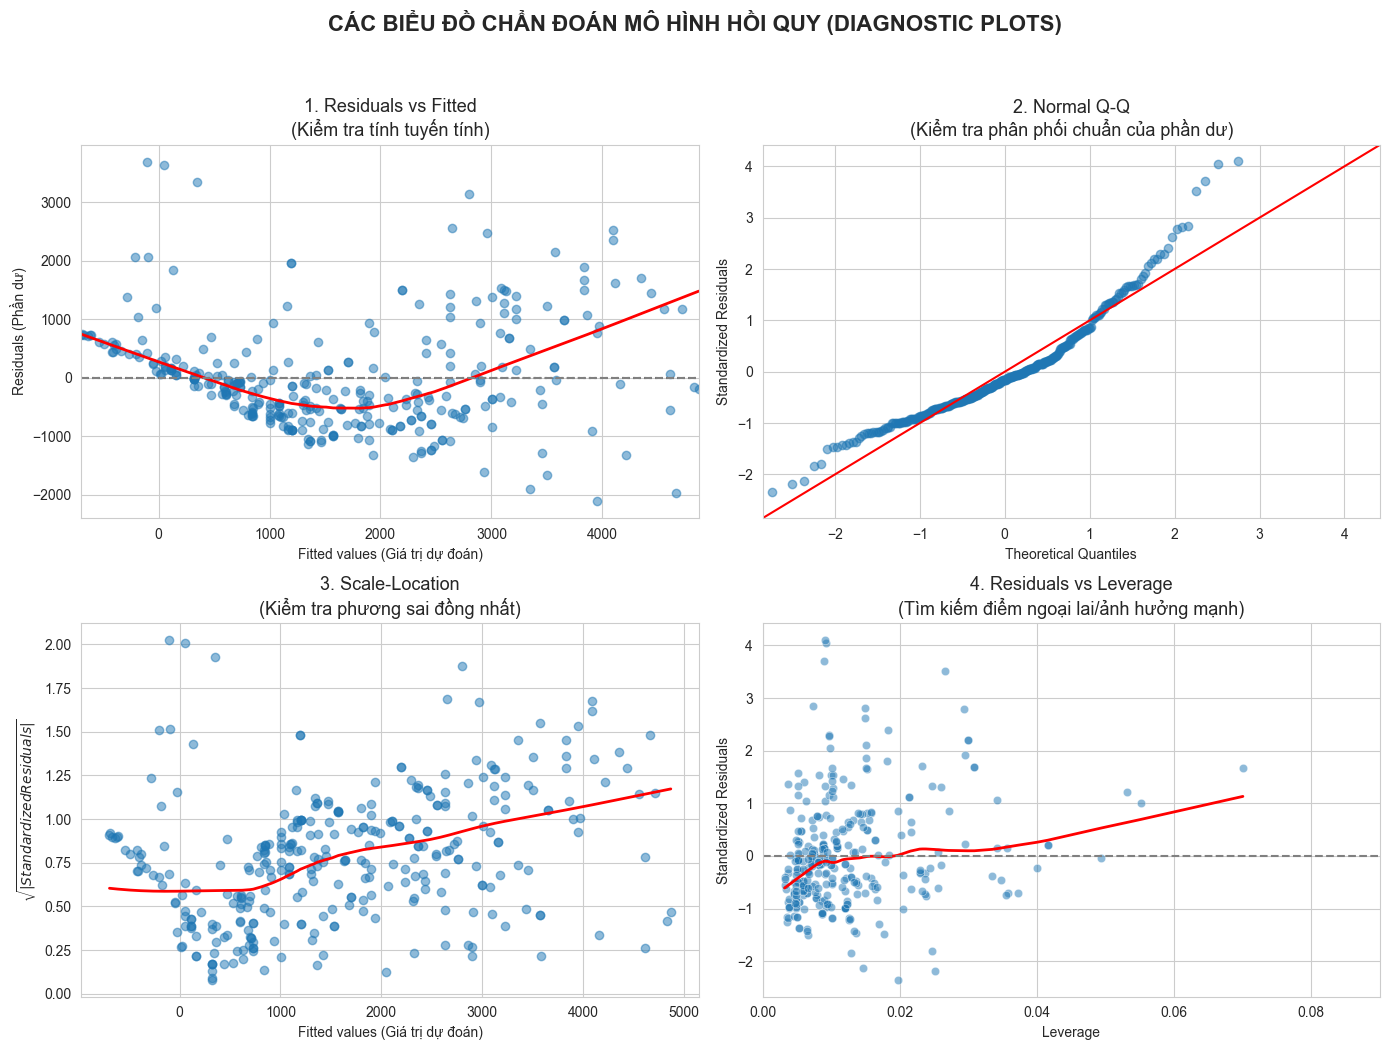

In [223]:
# Cài đặt phong cách đồ thị cho đẹp mắt
sns.set_style("whitegrid")

# Tạo một figure gồm 4 subplot (2 hàng x 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('CÁC BIỂU ĐỒ CHẨN ĐOÁN MÔ HÌNH HỒI QUY (DIAGNOSTIC PLOTS)', fontsize=16, fontweight='bold', y=0.98)

# Trích xuất các tham số cần thiết từ mô hình statsmodels
fitted_vals = model.fittedvalues
residuals = model.resid
student_resid = model.get_influence().resid_studentized_internal
leverage = model.get_influence().hat_matrix_diag

# ==========================================
# 1. Residuals vs Fitted
# ==========================================
sns.residplot(x=fitted_vals, y=residuals, lowess=True, 
              scatter_kws={'alpha': 0.5, 'color': '#1f77b4'}, 
              line_kws={'color': 'red', 'lw': 2}, ax=axes[0, 0])
axes[0, 0].set_title('1. Residuals vs Fitted\n(Kiểm tra tính tuyến tính)', fontsize=13)
axes[0, 0].set_xlabel('Fitted values (Giá trị dự đoán)')
axes[0, 0].set_ylabel('Residuals (Phần dư)')
axes[0, 0].axhline(0, color='grey', linestyle='dashed')

# ==========================================
# 2. Normal Q-Q
# ==========================================
sm.qqplot(student_resid, line='45', ax=axes[0, 1], alpha=0.5, color='#1f77b4')
axes[0, 1].set_title('2. Normal Q-Q\n(Kiểm tra phân phối chuẩn của phần dư)', fontsize=13)
axes[0, 1].set_xlabel('Theoretical Quantiles')
axes[0, 1].set_ylabel('Standardized Residuals')

# ==========================================
# 3. Scale-Location (Spread-Location)
# ==========================================
# Căn bậc hai của giá trị tuyệt đối phần dư chuẩn hóa
abs_sq_resid = np.sqrt(np.abs(student_resid))
sns.regplot(x=fitted_vals, y=abs_sq_resid, scatter=True, lowess=True,
            scatter_kws={'alpha': 0.5, 'color': '#1f77b4'},
            line_kws={'color': 'red', 'lw': 2}, ax=axes[1, 0])
axes[1, 0].set_title('3. Scale-Location\n(Kiểm tra phương sai đồng nhất)', fontsize=13)
axes[1, 0].set_xlabel('Fitted values (Giá trị dự đoán)')
axes[1, 0].set_ylabel(r'$\sqrt{|Standardized Residuals|}$')

# ==========================================
# 4. Residuals vs Leverage
# ==========================================
sns.scatterplot(x=leverage, y=student_resid, alpha=0.5, color='#1f77b4', ax=axes[1, 1])
sns.regplot(x=leverage, y=student_resid, scatter=False, lowess=True,
            line_kws={'color': 'red', 'lw': 2}, ax=axes[1, 1])
axes[1, 1].axhline(0, color='grey', linestyle='dashed')
axes[1, 1].set_xlim(0, max(leverage) + 0.02)
axes[1, 1].set_title('4. Residuals vs Leverage\n(Tìm kiếm điểm ngoại lai/ảnh hưởng mạnh)', fontsize=13)
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Standardized Residuals')

# Hiển thị đồ thị
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()